In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.colors as mplcolors
import matplotlib.patches as patches
import matplotlib.patheffects as pe
import matplotlib.dates as mdates
from SharedX import ShareXaxis
from UniversalColor import UniversalColor
from legend_shadow import legend_shadow
from scipy.io import readsav
from scipy.optimize import curve_fit
import spiceypy as spice

import JupiterMag as jm
import Leadangle_wave as LeadA

from Leadangle_fit_JunoUVS import Obsresults
from Leadangle_fit_JunoUVS import Obsresults_back
from Leadangle_fit_JunoUVS import calc_eqlead
from Leadangle_fit_JunoUVS import moonS3wlon_arr
from Leadangle_fit_JunoUVS import local_time_moon

import os

spice.furnsh('kernel/cassMetaK.txt')

UC = UniversalColor()
UC.set_palette()

Importing Library
done


In [2]:
# Input about Juno observation
TARGET_MOON = 'Ganymede'
TARGET_FP = ['MAW', 'TEB']
PJ_ALL = [1, 3]+np.arange(4, 68+1, 1).tolist()
USE_BACKTRACED = True

Zi = 1.4    # ION CHARGE [C] !!! CONSTANT !!!
Te = 20     # ELECTRON TEMPERATURE [eV] !!! CONSTANT !!!

In [3]:
# %% Constants
MU0 = 1.26E-6            # 真空中の透磁率
AMU2KG = 1.66E-27        # 原子質量をkgに変換するファクタ [kg]
RJ = 71492E+3            # JUPITER RADIUS [m]
MJ = 1.90E+27            # JUPITER MASS [kg]
C = 2.99792E+8           # LIGHT SPEED [m/s]
G = 6.67E-11             # 万有引力定数  [m^3 kg^-1 s^-2]

Psyn_io = (12.89)*3600      # Moon's synodic period [sec]
Psyn_eu = (11.22)*3600      # Moon's synodic period [sec]
Psyn_ga = (10.53)*3600      # Moon's synodic period [sec]

In [4]:
# %% Data from Connerney+2020: PJ index
con20_pj_idx = np.array([1, 3, 4, 5, 6,
                         7, 8, 9, 10, 11,
                         12, 13, 14, 15, 16,
                         17, 18, 19, 20, 21,
                         22, 23, 24], dtype=int)


# %% Data from Connerney+2020: Current constant [nT]
con20_mu_i_tot = np.array([150.1, 137.8, 127.2, 129.1, 130.1,
                           142.3, 140.1, 143.8, 137.0, 141.4,
                           124.2, 148.9, 145.3, 144.8, 149.9,
                           132.1, 133.5, 152.9, 138.5, 138.8,
                           156.1, 141.4, 146.3])


# %% Data from Connerney+2020: Radial current constant [MA]
con20_mu_i_rho = np.array([35.2, 14.6, 7.7, 11.5, 20.8,
                           20.2, 12.2, 21.1, 20.9, 10.7,
                           26.26, 16.4, 12.0, 19.6, 12.0,
                           13.6, 20.0, 12.8, 16.0, 17.3,
                           9.9, 16.1, 10.3])

In [5]:
PJ_LIST = con20_pj_idx[:-1].tolist()

In [6]:
wlon_fp, err_wlon_fp, lat_fp, err_lat_fp, moon_S3wlon, et_fp, hem_fp, pj_fp = Obsresults(
    PJ_LIST, TARGET_MOON, TARGET_FP, TARGET_HEM='both', FLIP=False
)

# Time: t0, the observation time
_, _, _, _, _, _, moon_S3wlon = moonS3wlon_arr(et_fp, TARGET_MOON)

eqlead_fp, eqlead_fp_0, eqlead_fp_1, wlon_fp_eq = calc_eqlead(wlon_fp,
                                                              err_wlon_fp,
                                                              lat_fp,
                                                              err_lat_fp,
                                                              hem_fp,
                                                              moon_S3wlon,
                                                              TARGET_MOON)

data_dir = 'data/Backtraced_Con2020/'
rho_eq = np.zeros(3)
phi_eq = np.zeros(3)
thick_coef_best = np.zeros(3)
for i in range(len(PJ_LIST)):
    data = np.loadtxt(
        data_dir+'PJ'+str(PJ_LIST[i]).zfill(2)+'/'+TARGET_MOON[0]+'FP_info_v900km.txt')
    rho_eq = np.append(rho_eq, data[0, :])
    phi_eq = np.append(phi_eq, data[1, :])
    thick_coef_best = np.append(thick_coef_best, data[5, :])

rho_eq = rho_eq[3:]     # [RJ]
phi_eq = phi_eq[3:]     # west longitude [deg]
thick_coef_best = thick_coef_best[3:]   # best-fit thickness coefficient

eqlead_fp = np.mod(moon_S3wlon-phi_eq, 360.0)

AttributeError: 'numpy.ndarray' object has no attribute 'text'

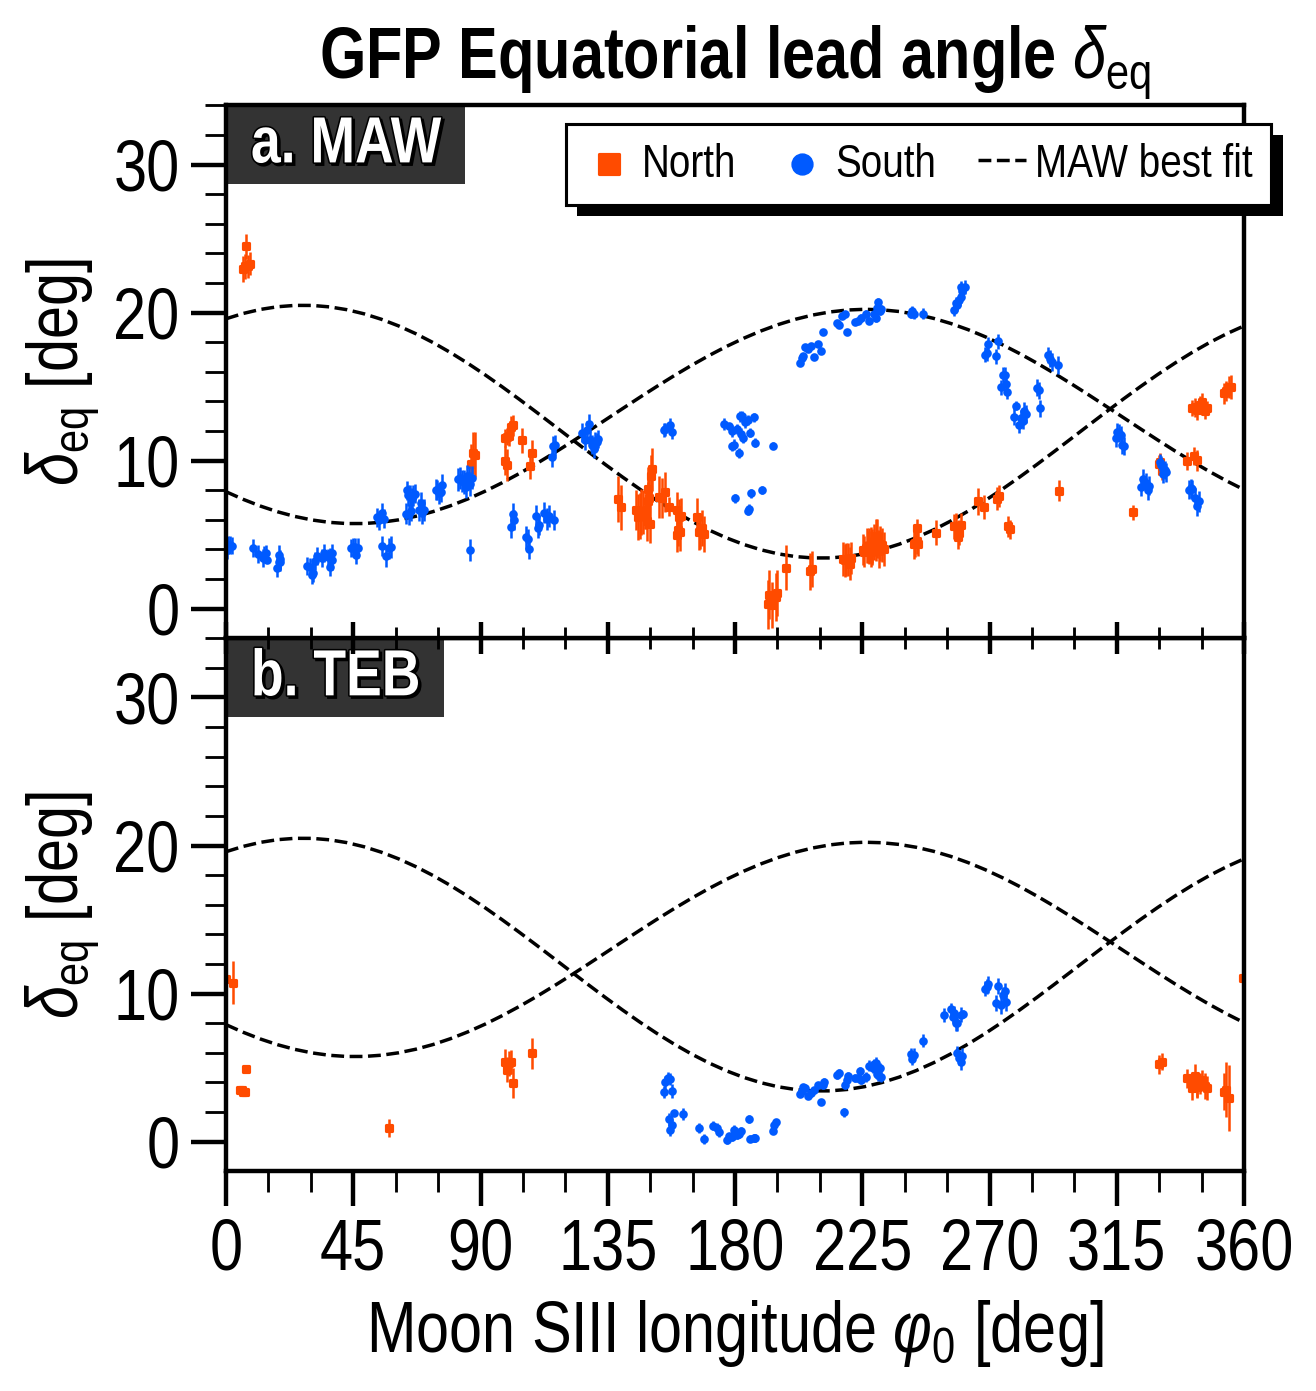

In [9]:
# %% ===============================================================================
# 横軸: Moon System III longitude [deg] / 縦軸: Footprint equatorial lead angle [deg]
# ==================================================================================
fig_id = 'SS260616.003'
F = ShareXaxis()
F.fontsize = 23
F.fontname = 'Liberation Sans Narrow'
F.wspace = 0.1

F.set_figparams(nrows=2, figsize=(6.0, 6.0), ticksize=1.5,
                dpi='L')
F.initialize()
F.panelname = [' a. MAW ', ' b. TEB ']

F.set_xaxis(label=r'Moon SIII longitude $\varphi_0$ [deg]',
            min=0, max=360,
            ticks=np.arange(0, 360+1, 45),
            ticklabels=np.arange(0, 360+1, 45),
            minor_num=3)

# F.fig.set_rasterized(True)
TARGET_MOON_LIST = ['Ganymede', 'Ganymede']
TARGET_FP_LIST = [['MAW'], ['TEB']]
for i in range(2):
    TARGET_MOON = TARGET_MOON_LIST[i]

    ymax = 1
    if TARGET_MOON == 'Io':
        ymin = -1
        ymax = 11
        dy = 5
    elif TARGET_MOON == 'Europa':
        ymin = -2
        ymax = 17
        dy = 5
    elif TARGET_MOON == 'Ganymede':
        ymin = -2
        ymax = 34
        dy = 10

    Psyn = Psyn_io

    F.set_yaxis(ax_idx=i, label=r'$\delta_{\rm eq}$ [deg]',
                min=ymin, max=ymax,
                ticks=np.arange(0, ymax+1, dy),
                ticklabels=np.arange(0, ymax+1, dy),
                minor_num=5)

for j in range(2):
    # All PJ
    north = np.where((hem_fp == -(1+100*j)))
    F.ax[j].scatter(moon_S3wlon[north], eqlead_fp[north],
                    color=UC.red, s=3.0,
                    marker='s',
                    label='North',
                    zorder=0.9)
    F.ax[j].errorbar(moon_S3wlon[north], eqlead_fp[north],
                     yerr=np.abs(eqlead_fp_0[north]),
                     linewidth=0., markersize=0,
                     elinewidth=0.8, color=UC.red,
                     zorder=0.9)

    # All PJ
    south = np.where((hem_fp == 1+100*j))
    F.ax[j].scatter(moon_S3wlon[south], eqlead_fp[south],
                    color=UC.blue, s=3.0,
                    label='South',
                    zorder=0.9)
    F.ax[j].errorbar(moon_S3wlon[south], eqlead_fp[south],
                     yerr=np.abs(eqlead_fp_0[south]),
                     linewidth=0., markersize=0,
                     elinewidth=0.8, color=UC.blue,
                     zorder=0.9)

    # From Hue+ 2023
    if TARGET_MOON == 'Io':
        lam = np.radians(np.linspace(0, 360, 60))
        delta_Hue_N = 4.16 + 2.48*np.cos(lam) \
            + 0.54*np.sin(lam) + 0.24*np.cos(2*lam) + 0.271*np.sin(2*lam)
        delta_Hue_S = 4.19 - 1.81*np.cos(1.001*lam) \
            - 0.72*np.sin(1.001*lam) + 0.336 * \
            np.cos(2*1.001*lam) - 0.15*np.sin(2*1.001*lam)
    elif TARGET_MOON == 'Europa':
        lam = np.radians(np.linspace(0, 360, 60))
        delta_Hue_N = 5.99 + 3.23*np.cos(lam) \
            + 1.65*np.sin(lam)
        delta_Hue_S = 7.10 - 3.46*np.cos(1.002*lam) \
            - 0.34*np.sin(1.002*lam)
    elif TARGET_MOON == 'Ganymede':
        lam = np.radians(np.linspace(0, 360, 60))
        delta_Hue_N = 11.95 + 7.63*np.cos(0.9828*lam) \
            + 3.85*np.sin(0.982*lam)
        delta_Hue_S = 12.98 - 5.08*np.cos(0.996*lam) \
            - 5.16*np.sin(0.996*lam)

    F.ax[j].plot(np.degrees(lam), delta_Hue_N,
                 linestyle='--', linewidth=1.1, color='k',
                 label='MAW best fit', zorder=0.5)
    F.ax[j].plot(np.degrees(lam), delta_Hue_S,
                 linestyle='--', linewidth=1.1, color='k',
                 zorder=0.5)

F.ax[0].set_title(
    TARGET_MOON[0]+'FP'+r' Equatorial lead angle $\delta_{\rm eq}$', fontsize=F.fontsize, weight='bold')

legend = F.legend(ax_idx=0, bbox_to_anchor=(1.05, 1.01),
                  ncol=3, markerscale=3.5,
                  fontsize_scale=0.65, textcolor=False, handletextpad=0.2)
legend_shadow(fig=F.fig, ax=F.ax[0], legend=legend, d=1.0)

F.manage(ax_idx=0, id=fig_id, color=UC.lightgray)

# F.fig.savefig('MAW_TEB_'+TARGET_MOON+'.pdf', bbox_inches='tight')
plt.show()

del F